In [1]:
import sys
print(sys.executable)

C:\Users\hp\OneDrive\Desktop\Emotion Detection\venv\Scripts\python.exe


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [7]:
train_path = "dataset/train"
val_path = "dataset/val"
test_path = "dataset/test"

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.


In [10]:
print(train_generator.class_indices)

{'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


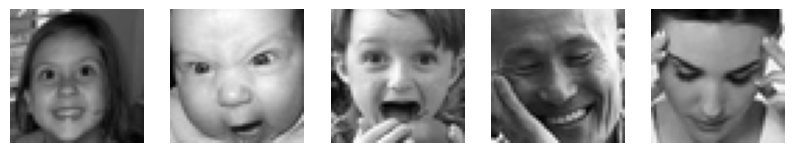

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

In [12]:
print(train_generator.class_indices)

{'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


In [14]:
import os

print(os.getcwd())
print(os.listdir())
print(os.path.exists("dataset"))
print(os.path.exists("dataset/train"))
print(os.path.exists("dataset/val"))
print(os.path.exists("dataset/test"))

C:\Users\hp\OneDrive\Desktop\Emotion Detection
['.ipynb_checkpoints', 'camera_test.py', 'dataset', 'emotion_detection.py', 'Emotion_Detection_Training.ipynb', 'venv']
True
True
True
True


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

model.summary()

C:\Users\hp\OneDrive\Desktop\Emotion Detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 50s 52ms/step - accuracy: 0.3000 - loss: 1.7237 - val_accuracy: 0.4065 - val_loss: 1.5312
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.4214 - loss: 1.4936 - val_accuracy: 0.4790 - val_loss: 1.3548
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.4740 - loss: 1.3781 - val_accuracy: 0.5104 - val_loss: 1.2915
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.5047 - loss: 1.3118 - val_accuracy: 0.5216 - val_loss: 1.2641
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.5277 - loss: 1.2531 - val_accuracy: 0.5261 - val_loss: 1.2288
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.5396 - loss: 1.2133 - val_accuracy: 0.5361 - val_loss: 1.2043
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.5568 - loss: 1.1756 - val_accuracy: 0.5492 - val_loss: 1.1960
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.5687 - loss: 1.1381 - 

In [22]:
model.save("emotion_model.h5")

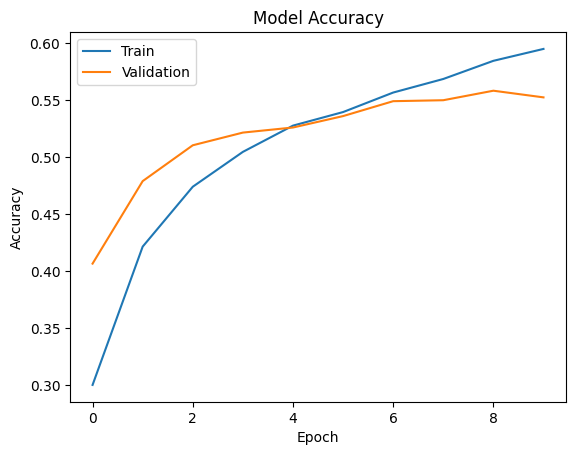

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [24]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5589 - loss: 1.1636
Test Accuracy: 0.5589300394058228


In [25]:
emotion_labels = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [26]:
import cv2

print(cv2.data.haarcascades)

C:\Users\hp\OneDrive\Desktop\Emotion Detection\venv\Lib\site-packages\cv2\data\


In [28]:
import cv2
import os

cascade_file = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

print(cascade_file)
print(os.path.exists(cascade_file))

C:\Users\hp\OneDrive\Desktop\Emotion Detection\venv\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
True
